# Revision Notebook (Exact from practice.py)

In [25]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./Titanic-Dataset.csv")

## 1) Programming Base (Practiced in practice.py)

In [15]:
data = [10, 20, 30, 40, 50]
maxi = max(data)
mini = min(data)
sumi = sum(data)
mean = sumi/len(data)

variance =(sum((x-mean)**2 for x in data))/len(data)
std_deviation = math.sqrt(variance)

print(max,min,sumi,mean,variance,std_deviation)

<built-in function max> <built-in function min> 150 30.0 200.0 14.142135623730951


## 2) Mathematics Foundation (Practiced in practice.py)

In [16]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c=np.dot(a,b)
print(a+b)
print(c)

x = np.array([1,2,3,4,5,6])
w=3
b=1


y=w*x+b
print(y)

z = np.array([10])
print(x+z)

a = np.array([[1,2,3],
              [4,5,6]])


b = a.reshape(2,-1)
print(b)
print(a.T)

[5 7 9]
32
[ 4  7 10 13 16 19]
[11 12 13 14 15 16]
[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]


In [17]:
print(np.random.randint(1,10))

print(np.random.randint(1,1000,size=(2,7)))

print(np.random.rand(2,3))
print(np.random.normal(0,1,(5,5)))

np.random.seed(42)
print(np.random.rand())
print(np.random.rand())

9
[[653 560 323 762 460 551 980]
 [395 500   5 817 722 336 250]]
[[0.39677638 0.67629779 0.90401923]
 [0.78242302 0.39052086 0.60785262]]
[[ 0.54944928 -1.05688387 -0.47414262  0.69906527 -0.687461  ]
 [-0.76393612  1.78480961 -1.59393719 -0.55512017  0.64003326]
 [-0.08256032  1.04544973 -1.89161329  2.11767073  1.58710746]
 [ 1.05314277 -0.83212666  0.48942549 -0.177739   -0.87294456]
 [-0.08537901 -0.16000318  0.2630536  -0.97652669 -0.23230351]]
0.3745401188473625
0.9507143064099162


## 3) Data Analysis (Practiced in practice.py)

In [18]:
print(df.describe())
print(df.duplicated().sum())
df["Age"].fillna(df["Age"].mean(),inplace=True)
print(df.duplicated().sum())
print(df.isnull().sum())

survived = df[(df["Survived"]==0 )& (df["Sex"]=="female")]
print(survived)

sorted =df.sort_values(["Age","Fare"],ascending=[True,False])
print(sorted)
group = df.groupby("Pclass").size()
print(group)


df["AgeGroup"]=df["Age"].apply(lambda x: "Child" if x<18 else "Adult")
print(df[(df["AgeGroup"]=="Child")])

       PassengerId    Survived      Pclass         Age       SibSp  \
count   183.000000  183.000000  183.000000  183.000000  183.000000   
mean    455.366120    0.672131    1.191257   35.674426    0.464481   
std     247.052476    0.470725    0.515187   15.643866    0.644159   
min       2.000000    0.000000    1.000000    0.920000    0.000000   
25%     263.500000    0.000000    1.000000   24.000000    0.000000   
50%     457.000000    1.000000    1.000000   36.000000    0.000000   
75%     676.000000    1.000000    1.000000   47.500000    1.000000   
max     890.000000    1.000000    3.000000   80.000000    3.000000   

            Parch        Fare  
count  183.000000  183.000000  
mean     0.475410   78.682469  
std      0.754617   76.347843  
min      0.000000    0.000000  
25%      0.000000   29.700000  
50%      0.000000   57.000000  
75%      1.000000   90.000000  
max      4.000000  512.329200  
0
0
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex      

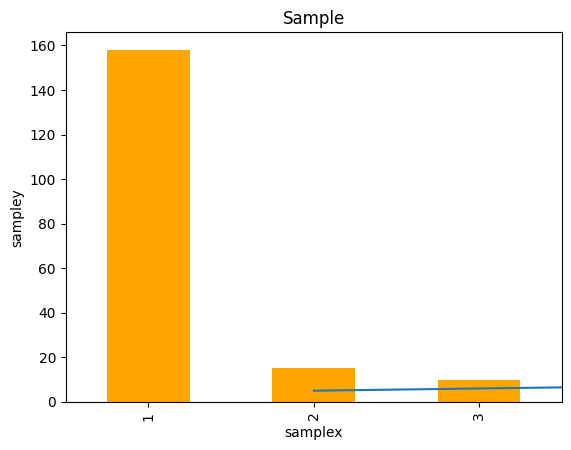

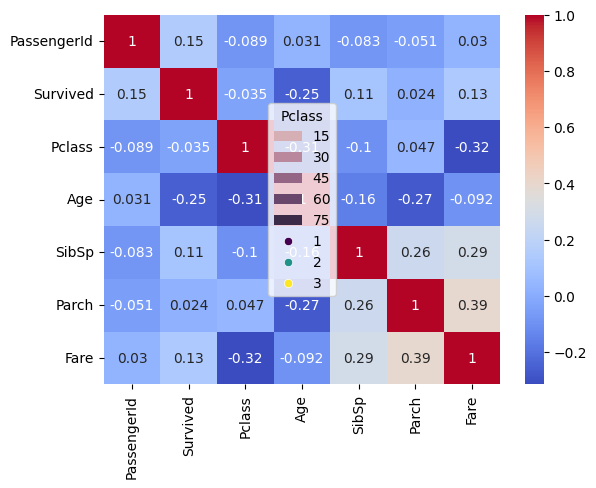

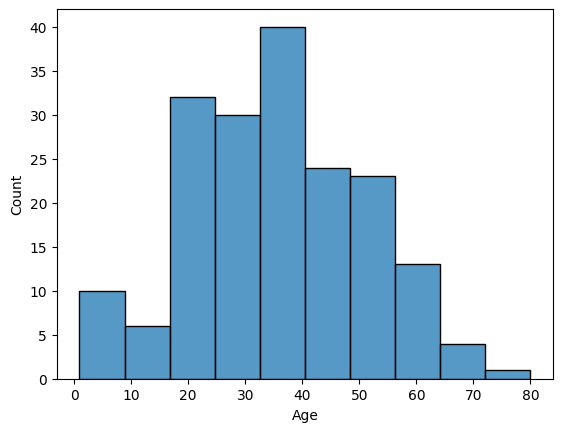

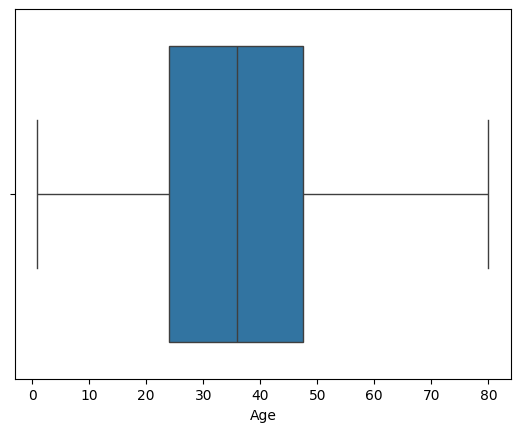

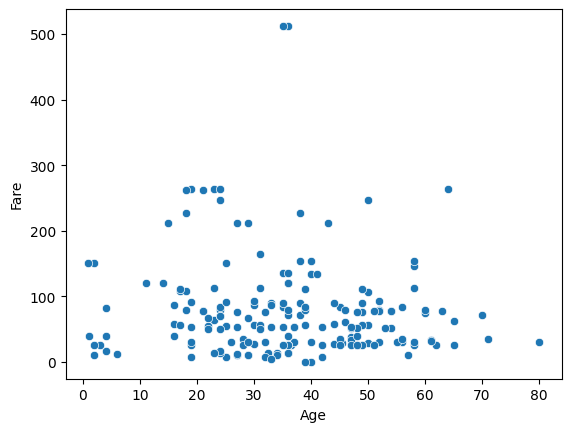

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


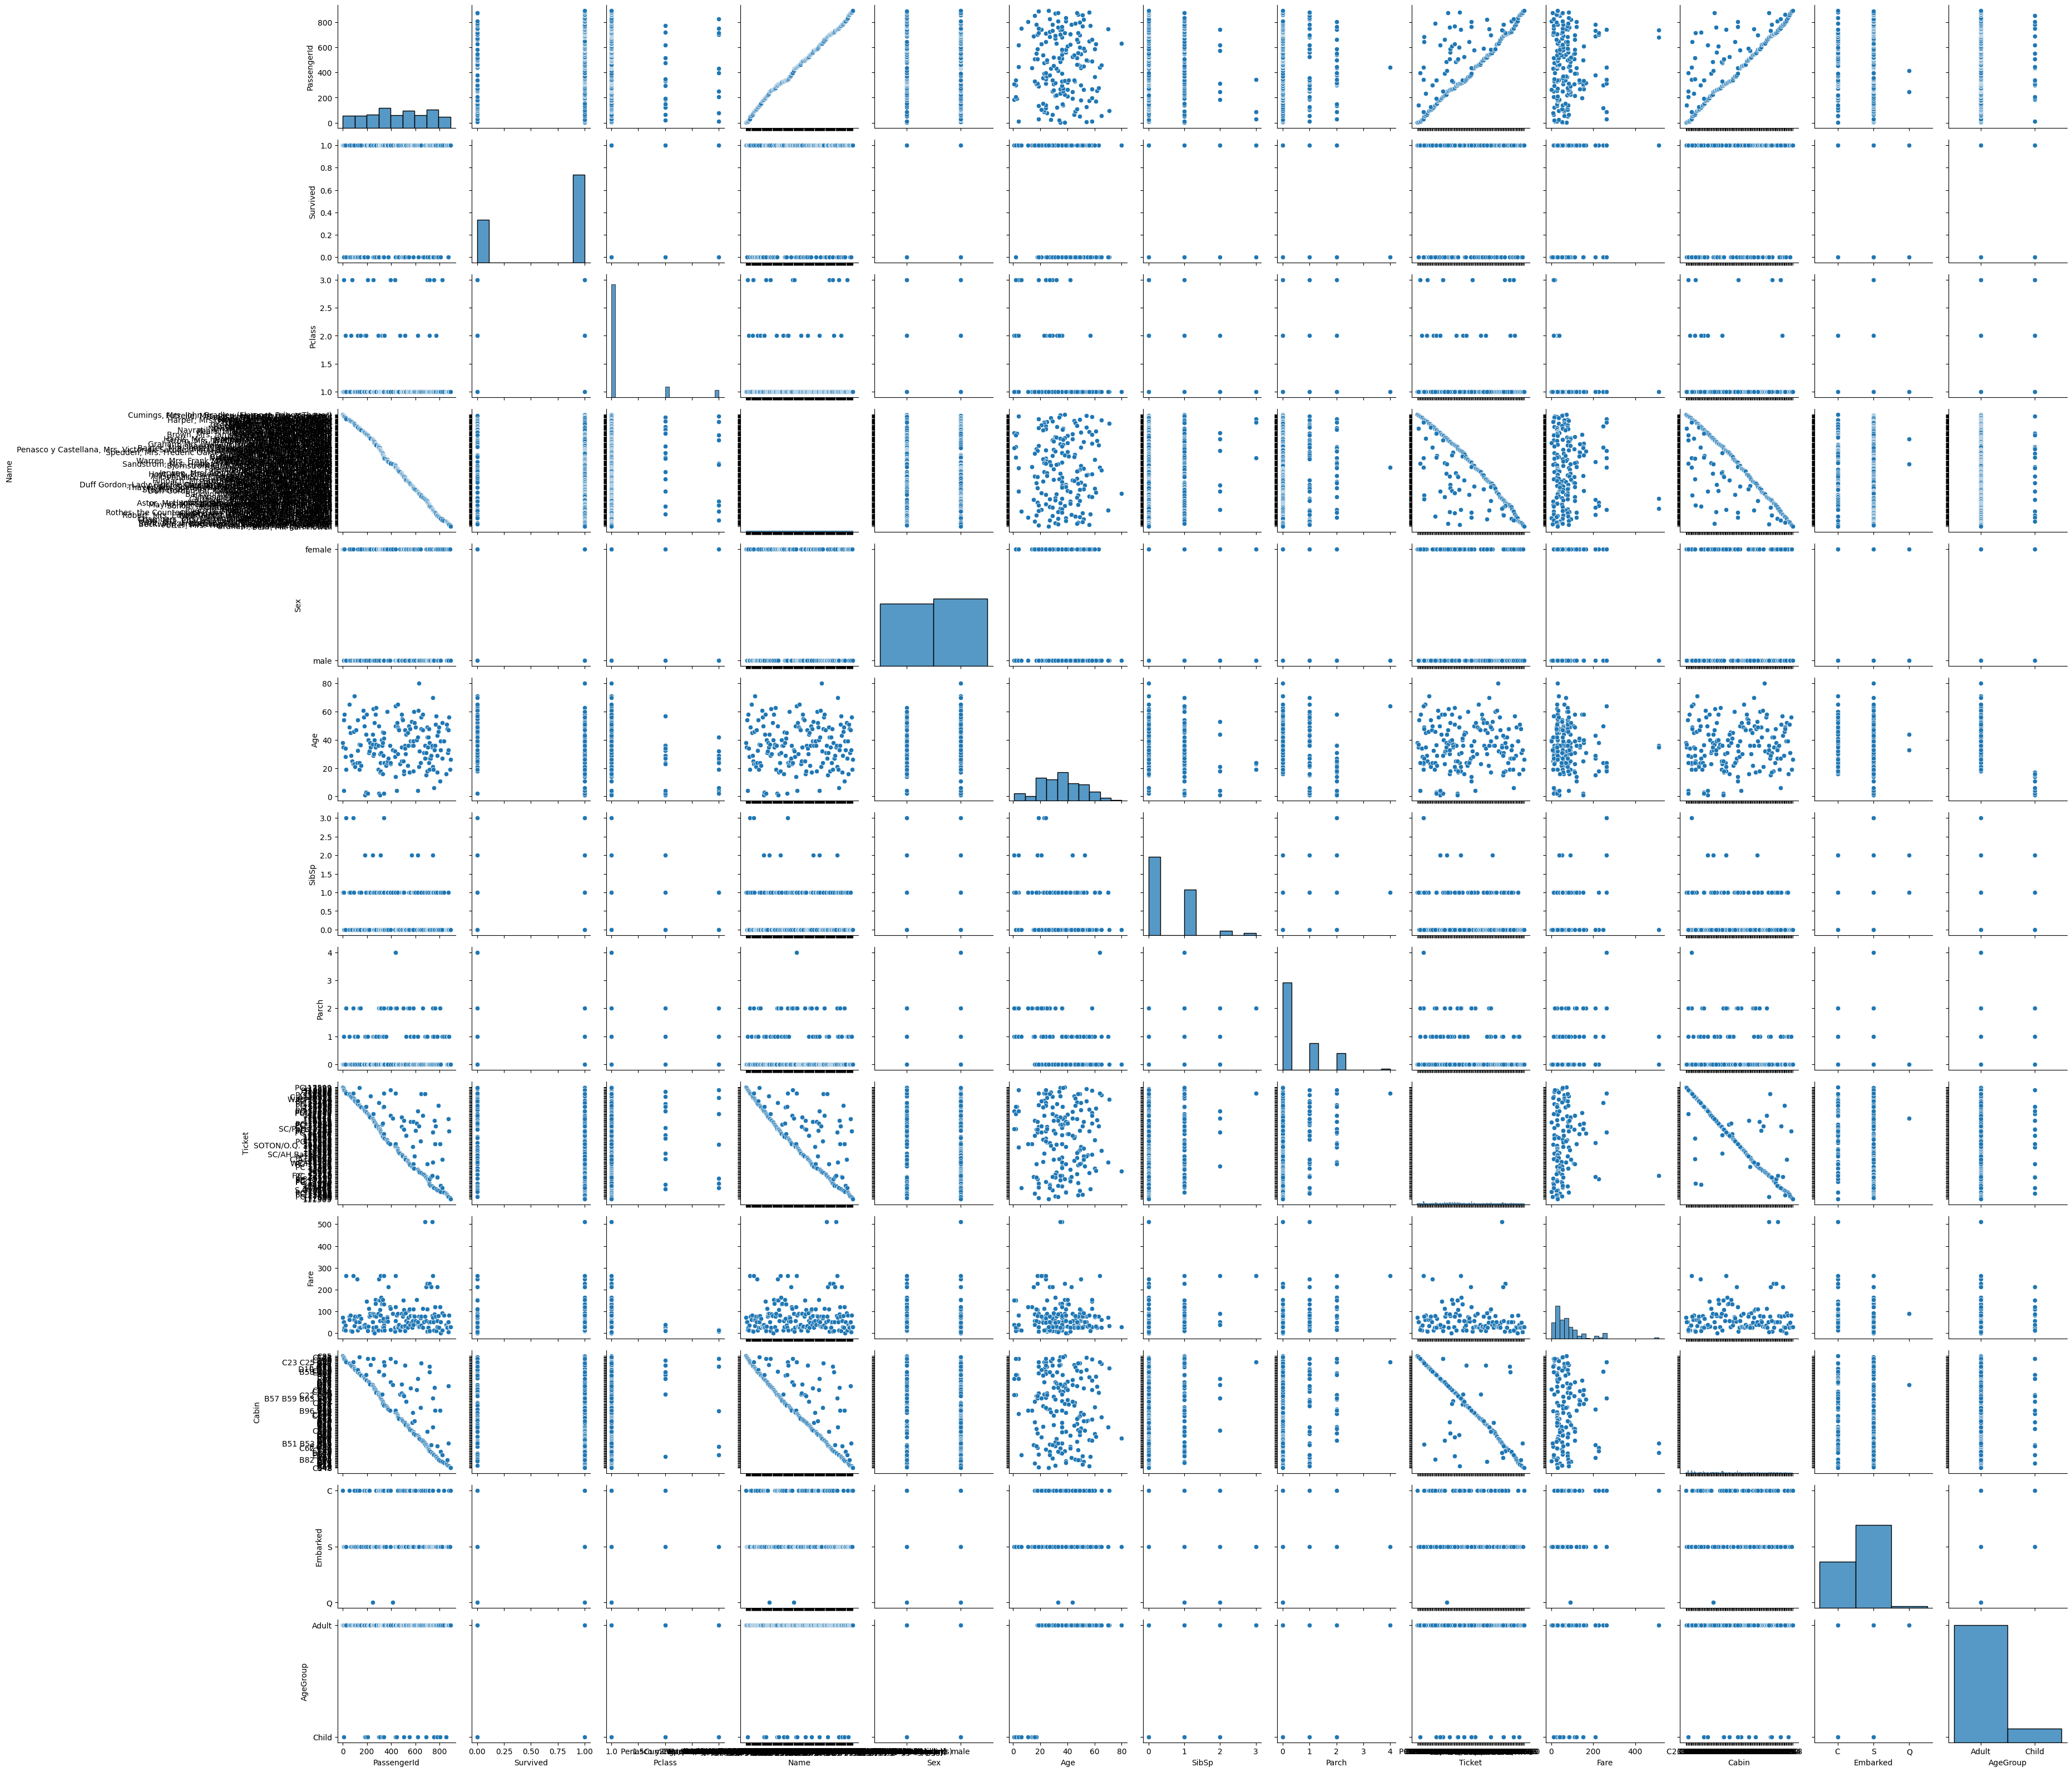

In [19]:
plt.plot([1,2,3,4],[5,6,7,8])
df['Pclass'].value_counts().plot(kind='bar', color='orange')
plt.title("Sample")
plt.xlabel("samplex")
plt.ylabel("sampley")
plt.show()

sns.countplot(data=df, x="Pclass",hue="Age")
sns.scatterplot(x="Age",y="Fare",data=df,hue="Pclass",palette='viridis')
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()
sns.histplot(data=df,x="Age",bins=10)
plt.show()
sns.boxplot(data=df,x="Age")
plt.show()
sns.scatterplot(data=df,x="Age",y="Fare")
plt.show()
sns.pairplot(data=df,x_vars=df.columns,y_vars=df.columns)
plt.show()

Data Preprocessing

In [3]:

print(df.info)
print(df.describe())
print(df.head())

Q1= df["Age"].quantile(0.25)
Q3= df["Age"].quantile(0.75)

IQR = Q3-Q1

min = Q1-1.5*IQR
max = Q3+1.5*IQR

outliers = (df[((df["Age"]>max) | (df["Age"]<min))])

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

Removing Outliers

In [26]:
print(df.isnull().sum())
df=df.dropna()
print(df.isnull().sum())
print(df.isnull().sum().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
0
